%% [markdown]
# Diabetes Classification — Clustering & Error Analysis

**Checkpoint 4.** Two final analyses:

1. **Clustering** — train clustering algorithms without using the labels, then check whether the natural structure agrees with the clinical labels. This is a different question than classification: not "can we predict the label?", but "does the data think there are 3 groups, and do they line up with N/P/Y?"
2. **Formal error analysis** — for both tracks, profile the misclassified patients. Which features are the model getting wrong on? Is there a pattern?

%% [markdown]
## 1. Setup & load prior artifacts

In [1]:
# %%
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (silhouette_score, adjusted_rand_score,
                              normalized_mutual_info_score,
                              calinski_harabasz_score,
                              accuracy_score, f1_score, confusion_matrix)
import umap

In [4]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 120

In [5]:
FIG_DIR = Path('/home/claude/c4_outputs')
ART_DIR = Path('/home/claude/c4_artifacts')
FIG_DIR.mkdir(exist_ok=True)
ART_DIR.mkdir(exist_ok=True)

In [6]:
CLASS_ORDER = ['N', 'P', 'Y']
CLASS_NAMES = {'N': 'Non-diabetic', 'P': 'Pre-diabetic', 'Y': 'Diabetic'}
PALETTE = {'N': '#2ecc71', 'P': '#f39c12', 'Y': '#e74c3c'}

In [7]:
# Load Checkpoint 2 artifacts (preprocessing + champion + splits)
with open('/home/claude/cls_artifacts/checkpoint2_artifacts.pkl', 'rb') as f:
    c2 = pickle.load(f)

In [8]:
with open('/home/claude/c3_artifacts/checkpoint3_artifacts.pkl', 'rb') as f:
    c3 = pickle.load(f)

In [9]:
X_train = c2['X_train']
X_test = c2['X_test']
y_train = c2['y_train']
y_test = c2['y_test']
TRACK_A_FEATURES = c2['TRACK_A_FEATURES']
TRACK_B_FEATURES = c2['TRACK_B_FEATURES']
le = c2['label_encoder']
champion_A = c2['champion_A']
champion_B_untuned = c2['champion_B']

In [10]:
X_full = pd.concat([X_train, X_test], axis=0)
y_full = pd.concat([y_train, y_test], axis=0)
print(f"Full dataset (after preprocessing): {X_full.shape}")
print(f"Class distribution: {y_full.value_counts().to_dict()}")

Full dataset (after preprocessing): (826, 11)
Class distribution: {'Y': 690, 'N': 96, 'P': 40}


%% [markdown]
## 2. Clustering setup

A subtle but important choice: cluster on which feature set?

* **With HbA1c**: trivially recovers the 3 classes (since HbA1c is the label). Validates that classes exist.
* **Without HbA1c**: the genuinely interesting question — does the remaining metabolic signal cluster into the same 3 groups?

We run both. Track-A-features clustering is the sanity check; Track-B-features clustering is the real test.

In [11]:
# %%
scaler = StandardScaler()
X_full_A_scaled = scaler.fit_transform(X_full[TRACK_A_FEATURES])
scaler_B = StandardScaler()
X_full_B_scaled = scaler_B.fit_transform(X_full[TRACK_B_FEATURES])

In [12]:
y_full_arr = y_full.values

%% [markdown]
## 3. How many clusters does the data think there are?

Before assuming k=3 (which is what the labels say), let's let the data speak. Run silhouette and Calinski-Harabasz scores for k=2..7.

In [13]:
# %%
def cluster_quality_sweep(X_scaled, k_range=range(2, 8)):
    """Returns silhouette + Calinski-Harabasz for KMeans across k."""
    rows = []
    for k in k_range:
        km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
        labels = km.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labels)
        ch = calinski_harabasz_score(X_scaled, labels)
        rows.append({'k': k, 'silhouette': sil, 'calinski_harabasz': ch,
                     'inertia': km.inertia_})
    return pd.DataFrame(rows)

In [14]:
sweep_A = cluster_quality_sweep(X_full_A_scaled)
sweep_B = cluster_quality_sweep(X_full_B_scaled)

In [15]:
print("Cluster-quality sweep — Track A features (with HbA1c):")
print(sweep_A.round(3).to_string(index=False))
print("\nCluster-quality sweep — Track B features (without HbA1c):")
print(sweep_B.round(3).to_string(index=False))

Cluster-quality sweep — Track A features (with HbA1c):
 k  silhouette  calinski_harabasz  inertia
 2       0.162            129.263 7853.934
 3       0.176            121.474 7015.138
 4       0.200            123.773 6258.757
 5       0.159            124.206 5660.548
 6       0.162            119.737 5251.704
 7       0.170            116.303 4905.955

Cluster-quality sweep — Track B features (without HbA1c):
 k  silhouette  calinski_harabasz  inertia
 2       0.132            106.796 7312.278
 3       0.138            111.062 6504.473
 4       0.166            117.373 5782.825
 5       0.155            123.675 5154.259
 6       0.161            121.988 4736.699
 7       0.174            120.609 4385.269


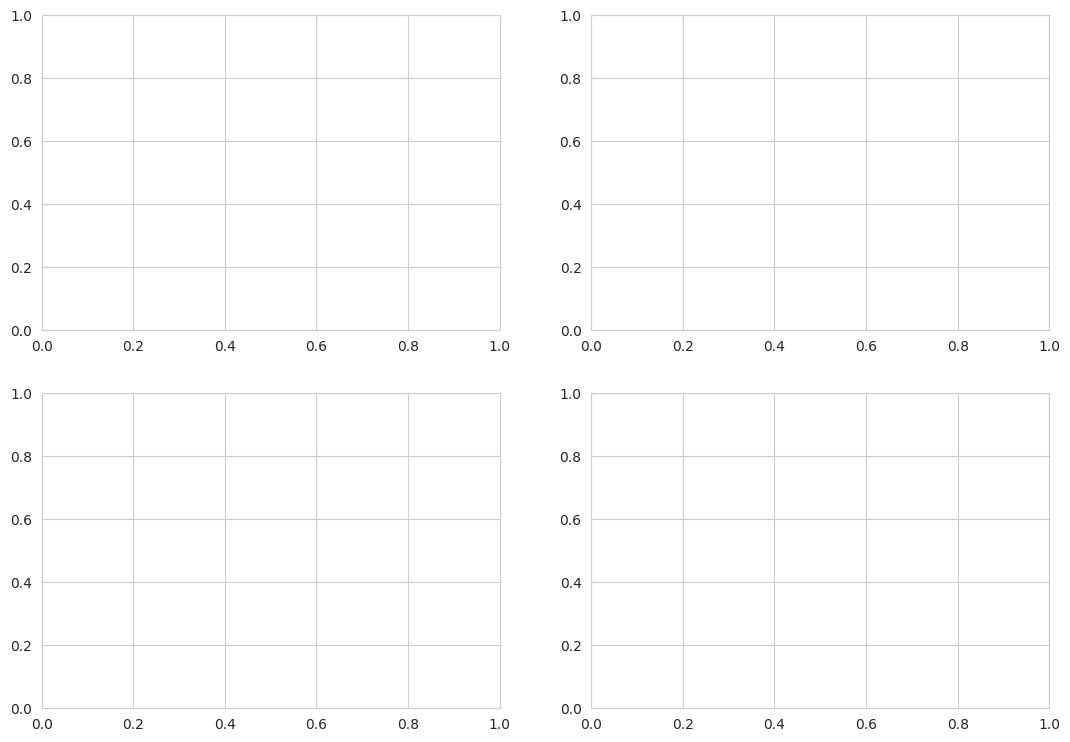

In [16]:
# %%
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

In [17]:
for col, (name, sweep) in enumerate([('Track A (with HbA1c)', sweep_A),
                                      ('Track B (without HbA1c)', sweep_B)]):
    ax = axes[0, col]
    ax.plot(sweep['k'], sweep['silhouette'], 'o-', color='#3498db', linewidth=2, markersize=8)
    ax.set_xlabel('Number of clusters (k)', fontsize=10)
    ax.set_ylabel('Silhouette score', fontsize=10)
    ax.set_title(f'{name}\nSilhouette by k', fontsize=11, fontweight='bold')
    ax.axvline(3, color='red', linestyle='--', alpha=0.5, label='k=3 (true class count)')
    ax.legend(fontsize=9)
    sns.despine(ax=ax)

    ax = axes[1, col]
    ax.plot(sweep['k'], sweep['inertia'], 'o-', color='#e74c3c', linewidth=2, markersize=8)
    ax.set_xlabel('Number of clusters (k)', fontsize=10)
    ax.set_ylabel('Inertia (within-cluster SS)', fontsize=10)
    ax.set_title('Elbow plot', fontsize=11, fontweight='bold')
    ax.axvline(3, color='red', linestyle='--', alpha=0.5)
    sns.despine(ax=ax)

In [18]:
fig.suptitle('How many natural clusters does each feature set support?',
             fontsize=13, fontweight='bold')
fig.subplots_adjust(top=0.91, hspace=0.4, wspace=0.25)
fig.savefig(FIG_DIR / 'cluster_quality_sweep.png', dpi=120)
plt.show()

%% [markdown]
**What to look for:**

* If silhouette peaks at k=3 → clinical labels match natural structure.
* If it peaks elsewhere → the natural grouping of patients in feature space disagrees with the clinical labels (interesting medically — maybe metabolic subtypes).
* If silhouette is generally low (< 0.3) → no strong clustering structure at all; the labels are useful but the data is fundamentally a continuum, not discrete groups.

%% [markdown]
## 4. Three clustering algorithms at k=3

K-means (centroid-based), Gaussian Mixture (probabilistic, allows elliptical clusters), and Agglomerative (hierarchical, linkage-based). Different inductive biases — comparing them shows whether the result is algorithm-dependent or robust.

In [19]:
# %%
def cluster_and_compare(X_scaled, y_true, k=3):
    """Run 3 clustering algorithms and compare against true labels."""
    results = {}

    algorithms = {
        'KMeans':        KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE),
        'GMM':           GaussianMixture(n_components=k, n_init=10,
                                          covariance_type='full',
                                          random_state=RANDOM_STATE),
        'Agglomerative': AgglomerativeClustering(n_clusters=k, linkage='ward'),
    }

    for name, algo in algorithms.items():
        if hasattr(algo, 'fit_predict'):
            labels = algo.fit_predict(X_scaled)
        else:
            algo.fit(X_scaled)
            labels = algo.predict(X_scaled)

        sil = silhouette_score(X_scaled, labels)
        ari = adjusted_rand_score(y_true, labels)
        nmi = normalized_mutual_info_score(y_true, labels)
        results[name] = {
            'labels': labels,
            'silhouette': sil,
            'ari': ari,
            'nmi': nmi,
        }
    return results

In [20]:
results_A = cluster_and_compare(X_full_A_scaled, y_full_arr, k=3)
results_B = cluster_and_compare(X_full_B_scaled, y_full_arr, k=3)

In [21]:
# Comparison table
rows = []
for track_name, results in [('Track A (with HbA1c)', results_A),
                             ('Track B (without HbA1c)', results_B)]:
    for algo_name, m in results.items():
        rows.append({
            'feature_set': track_name,
            'algorithm': algo_name,
            'silhouette': m['silhouette'],
            'ARI (vs true)': m['ari'],
            'NMI (vs true)': m['nmi'],
        })
clustering_comparison = pd.DataFrame(rows)
print("\nClustering quality comparison:")
print(clustering_comparison.round(3).to_string(index=False))


Clustering quality comparison:
            feature_set     algorithm  silhouette  ARI (vs true)  NMI (vs true)
   Track A (with HbA1c)        KMeans       0.176          0.503          0.389
   Track A (with HbA1c)           GMM       0.123         -0.007          0.015
   Track A (with HbA1c) Agglomerative       0.144          0.422          0.275
Track B (without HbA1c)        KMeans       0.138          0.403          0.305
Track B (without HbA1c)           GMM       0.057         -0.007          0.022
Track B (without HbA1c) Agglomerative       0.308         -0.079          0.015


%% [markdown]
**Reading these metrics:**

* **Silhouette ∈ [-1, 1]**: how well-separated the discovered clusters are. >0.5 strong, 0.25-0.5 reasonable, <0.25 weak.
* **ARI ∈ [-1, 1]**: agreement between cluster labels and true labels, corrected for chance. 0 = random, 1 = perfect.
* **NMI ∈ [0, 1]**: information-theoretic agreement. Less sensitive to imbalance than ARI.

%% [markdown]
## 5. Confusion matrices — clustering vs clinical labels

In [22]:
# %%
def cluster_label_confusion(cluster_labels, true_labels):
    """Build a confusion matrix between cluster IDs and true class labels."""
    df = pd.DataFrame({'cluster': cluster_labels, 'true': true_labels})
    return pd.crosstab(df['cluster'], df['true'], rownames=['Cluster'], colnames=['True class'])

In [23]:
# Best-performing algorithm for each track (by ARI)
best_A = max(results_A, key=lambda n: results_A[n]['ari'])
best_B = max(results_B, key=lambda n: results_B[n]['ari'])

In [24]:
print(f"\nBest clustering for Track A: {best_A} (ARI = {results_A[best_A]['ari']:.3f})")
print(cluster_label_confusion(results_A[best_A]['labels'], y_full_arr))
print(f"\nBest clustering for Track B: {best_B} (ARI = {results_B[best_B]['ari']:.3f})")
print(cluster_label_confusion(results_B[best_B]['labels'], y_full_arr))


Best clustering for Track A: KMeans (ARI = 0.503)
True class   N   P    Y
Cluster                
0            3   1   31
1            2   1  584
2           91  38   75

Best clustering for Track B: KMeans (ARI = 0.403)
True class   N   P    Y
Cluster                
0            3   1   31
1           89  36  102
2            4   3  557


%% [markdown]
**How to read these:** Each row is a discovered cluster, each column is a true class. A "clean" clustering would have each row dominated by one column (and each column dominated by one row). Smearing across rows = the cluster doesn't correspond to a single class.

%% [markdown]
## 6. UMAP 2D visualization

Project the high-dimensional feature space to 2D with UMAP (preserves local neighborhood structure better than PCA for clustering visualization), then color by both true labels and cluster labels. This is the most intuitive way to see what's happening.

In [25]:
# %%
print("Computing UMAP embeddings…")
reducer_A = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=RANDOM_STATE)
emb_A = reducer_A.fit_transform(X_full_A_scaled)

Computing UMAP embeddings…


In [26]:
reducer_B = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=RANDOM_STATE)
emb_B = reducer_B.fit_transform(X_full_B_scaled)
print("Done.")

Done.


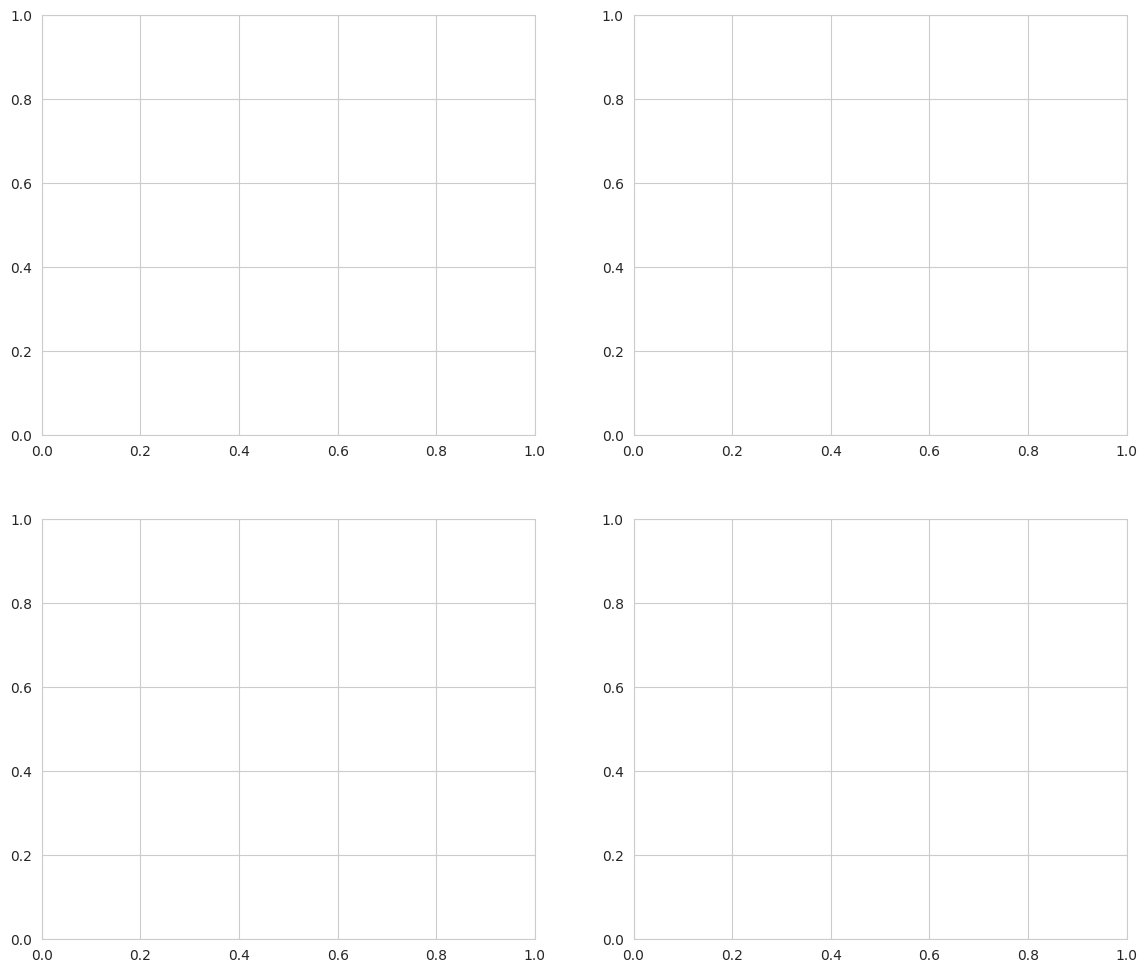

In [27]:
# %%
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

In [28]:
# Track A — true labels
ax = axes[0, 0]
for cls in CLASS_ORDER:
    mask = y_full_arr == cls
    ax.scatter(emb_A[mask, 0], emb_A[mask, 1], c=PALETTE[cls],
               label=f'{CLASS_NAMES[cls]} (n={mask.sum()})',
               alpha=0.7, s=20, edgecolors='white', linewidth=0.3)
ax.set_title('Track A · UMAP · TRUE labels\n(with HbA1c — should be clean)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
ax.legend(fontsize=9, loc='best')

In [29]:
# Track A — best cluster
ax = axes[0, 1]
labels_A = results_A[best_A]['labels']
cluster_palette = ['#3498db', '#9b59b6', '#1abc9c']
for k in sorted(np.unique(labels_A)):
    mask = labels_A == k
    ax.scatter(emb_A[mask, 0], emb_A[mask, 1], c=cluster_palette[k % 3],
               label=f'Cluster {k} (n={mask.sum()})',
               alpha=0.7, s=20, edgecolors='white', linewidth=0.3)
ax.set_title(f'Track A · UMAP · {best_A} clusters\n(ARI vs true: {results_A[best_A]["ari"]:.3f})',
             fontsize=11, fontweight='bold')
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
ax.legend(fontsize=9, loc='best')

In [30]:
# Track B — true labels
ax = axes[1, 0]
for cls in CLASS_ORDER:
    mask = y_full_arr == cls
    ax.scatter(emb_B[mask, 0], emb_B[mask, 1], c=PALETTE[cls],
               label=f'{CLASS_NAMES[cls]} (n={mask.sum()})',
               alpha=0.7, s=20, edgecolors='white', linewidth=0.3)
ax.set_title('Track B · UMAP · TRUE labels\n(without HbA1c — the real test)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
ax.legend(fontsize=9, loc='best')

In [31]:
# Track B — best cluster
ax = axes[1, 1]
labels_B = results_B[best_B]['labels']
for k in sorted(np.unique(labels_B)):
    mask = labels_B == k
    ax.scatter(emb_B[mask, 0], emb_B[mask, 1], c=cluster_palette[k % 3],
               label=f'Cluster {k} (n={mask.sum()})',
               alpha=0.7, s=20, edgecolors='white', linewidth=0.3)
ax.set_title(f'Track B · UMAP · {best_B} clusters\n(ARI vs true: {results_B[best_B]["ari"]:.3f})',
             fontsize=11, fontweight='bold')
ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
ax.legend(fontsize=9, loc='best')

In [32]:
fig.suptitle('Clinical labels vs unsupervised clusters in 2D feature space',
             fontsize=13, fontweight='bold')
fig.subplots_adjust(top=0.93, hspace=0.3, wspace=0.2)
fig.savefig(FIG_DIR / 'umap_clusters.png', dpi=120)
plt.show()

%% [markdown]
**What to look for in the UMAP panels:**

* **Track A (top row)** should show 3 distinct groups for both true labels and clusters — HbA1c forces clean separation.
* **Track B (bottom row)** is the interesting comparison. If true-label panel shows obvious overlap but the cluster panel shows clean separation → clusters found structure that disagrees with clinical labels. If both show similar mess → labels and structure agree but the data fundamentally doesn't have crisp boundaries.

%% [markdown]
## 7. Comparison: clustering vs classification

Side-by-side: how does each approach map to the clinical labels?

In [33]:
# %%
# Best Track B cluster's effective "accuracy" if we map each cluster to its majority class
def cluster_majority_accuracy(cluster_labels, true_labels):
    """For each cluster, predict majority class; compute accuracy."""
    df = pd.DataFrame({'cluster': cluster_labels, 'true': true_labels})
    mapping = df.groupby('cluster')['true'].agg(lambda x: x.value_counts().index[0])
    df['pred'] = df['cluster'].map(mapping)
    return accuracy_score(df['true'], df['pred']), f1_score(df['true'], df['pred'],
                                                              average='macro', labels=CLASS_ORDER)

In [34]:
acc_clu_A, f1_clu_A = cluster_majority_accuracy(results_A[best_A]['labels'], y_full_arr)
acc_clu_B, f1_clu_B = cluster_majority_accuracy(results_B[best_B]['labels'], y_full_arr)

In [35]:
print("Clustering reframed as classification (majority-vote per cluster):")
print(f"  Track A · {best_A}:  accuracy={acc_clu_A:.4f}  macro F1={f1_clu_A:.4f}")
print(f"  Track B · {best_B}:  accuracy={acc_clu_B:.4f}  macro F1={f1_clu_B:.4f}")
print("\nCompared to supervised classification on the held-out test set:")
print(f"  Track A · XGBoost:   accuracy=0.9940  macro F1=0.9898")
print(f"  Track B · XGBoost:   accuracy=0.9639  macro F1=0.8573")

Clustering reframed as classification (majority-vote per cluster):
  Track A · KMeans:  accuracy=0.8547  macro F1=0.5147
  Track B · KMeans:  accuracy=0.8354  macro F1=0.3034

Compared to supervised classification on the held-out test set:
  Track A · XGBoost:   accuracy=0.9940  macro F1=0.9898
  Track B · XGBoost:   accuracy=0.9639  macro F1=0.8573


%% [markdown]
## 8. Error analysis — where do classification models fail?

Take the held-out test predictions from both tracks. Profile the misclassified patients to identify common patterns.

In [36]:
# %%
# Get test predictions from both champion models
y_test_arr = y_test.values

In [37]:
# Track A
pred_A = le.inverse_transform(champion_A.predict(X_test[TRACK_A_FEATURES]))
err_A_mask = pred_A != y_test_arr

In [38]:
# Track B (untuned — our chosen production model from C3)
champion_B_untuned.fit(X_train[TRACK_B_FEATURES], le.transform(y_train))
pred_B = le.inverse_transform(champion_B_untuned.predict(X_test[TRACK_B_FEATURES]))
err_B_mask = pred_B != y_test_arr

In [39]:
print(f"Track A errors: {err_A_mask.sum()} of {len(y_test_arr)} ({err_A_mask.mean()*100:.1f}%)")
print(f"Track B errors: {err_B_mask.sum()} of {len(y_test_arr)} ({err_B_mask.mean()*100:.1f}%)")

Track A errors: 1 of 166 (0.6%)
Track B errors: 6 of 166 (3.6%)


%% [markdown]
### 8.1 Per-class error breakdown

In [40]:
# %%
error_summary_rows = []
for track_name, mask, preds in [('A', err_A_mask, pred_A), ('B', err_B_mask, pred_B)]:
    for true_cls in CLASS_ORDER:
        true_mask = y_test_arr == true_cls
        errors = (true_mask & mask).sum()
        total = true_mask.sum()
        for pred_cls in CLASS_ORDER:
            if pred_cls == true_cls:
                continue
            n_misclas = ((y_test_arr == true_cls) & (preds == pred_cls)).sum()
            if n_misclas > 0:
                error_summary_rows.append({
                    'track': track_name,
                    'true_class': true_cls,
                    'pred_class': pred_cls,
                    'count': n_misclas,
                    'pct_of_true_class': n_misclas / total * 100
                })
error_summary = pd.DataFrame(error_summary_rows)
print("\nError breakdown by true → predicted class:")
print(error_summary.to_string(index=False))


Error breakdown by true → predicted class:
track true_class pred_class  count  pct_of_true_class
    A          N          Y      1           5.263158
    B          N          Y      1           5.263158
    B          P          N      1          12.500000
    B          P          Y      3          37.500000
    B          Y          N      1           0.719424


%% [markdown]
### 8.2 Profile of misclassified Track B patients

What do the patients Track B got wrong look like compared to the correctly classified ones?

In [41]:
# %%
# Add prediction columns to the test set for analysis
X_test_an = X_test.copy()
X_test_an['true'] = y_test_arr
X_test_an['pred_B'] = pred_B
X_test_an['correct_B'] = ~err_B_mask

In [42]:
# Compare feature means: correctly classified vs misclassified, within each true class
features_to_profile = ['AGE', 'BMI', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'Urea', 'Cr', 'VLDL']

In [43]:
profile_rows = []
for true_cls in CLASS_ORDER:
    subset = X_test_an[X_test_an['true'] == true_cls]
    if len(subset) < 2:
        continue
    correct_subset = subset[subset['correct_B']]
    error_subset = subset[~subset['correct_B']]
    if len(error_subset) == 0:
        continue
    row = {'true_class': true_cls, 'n_correct': len(correct_subset), 'n_error': len(error_subset)}
    for feat in features_to_profile:
        row[f'{feat}_correct'] = correct_subset[feat].mean() if len(correct_subset) > 0 else np.nan
        row[f'{feat}_error']   = error_subset[feat].mean()
    profile_rows.append(row)

In [44]:
profile_df = pd.DataFrame(profile_rows)
print("\nFeature means: correctly vs misclassified Track B patients (by true class):")
print(profile_df.round(2).to_string(index=False))


Feature means: correctly vs misclassified Track B patients (by true class):
true_class  n_correct  n_error  AGE_correct  AGE_error  BMI_correct  BMI_error  HbA1c_correct  HbA1c_error  Chol_correct  Chol_error  TG_correct  TG_error  HDL_correct  HDL_error  LDL_correct  LDL_error  Urea_correct  Urea_error  Cr_correct  Cr_error  VLDL_correct  VLDL_error
         N         18        1        46.00       30.0        22.06      20.00           4.78         5.50          4.43         5.5        1.75      1.80         1.03       1.20         2.84       3.50          4.78        4.80       62.78     80.00          0.96        0.80
         P          4        4        49.50       37.5        24.25      26.00           6.10         5.92          3.46         4.6        2.10      2.43         1.08       1.35         1.60       2.38          4.27        5.05       65.25     61.75          0.80        1.22
         Y        138        1        55.22       33.0        31.08      21.17           9.3

%% [markdown]
### 8.3 Visualize the misclassified P-patients' positions

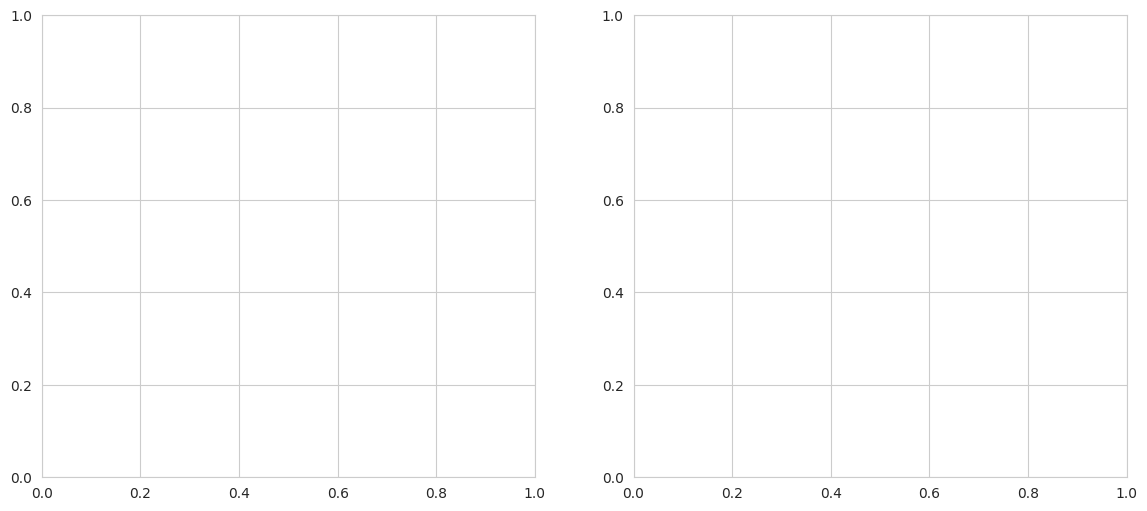

In [45]:
# %%
# Highlight Track B misclassified P-patients in HbA1c vs BMI space
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

In [46]:
# Panel 1: all test patients in HbA1c vs BMI, colored by true class, with Track B errors highlighted
ax = axes[0]
for cls in CLASS_ORDER:
    mask = (y_test_arr == cls) & (~err_B_mask)
    ax.scatter(X_test.loc[mask, 'HbA1c'], X_test.loc[mask, 'BMI'],
               c=PALETTE[cls], alpha=0.6, s=40, label=f'{CLASS_NAMES[cls]} (correct)',
               edgecolors='white', linewidth=0.5)
# Errors with black X marker
for cls in CLASS_ORDER:
    mask = (y_test_arr == cls) & err_B_mask
    if mask.sum() > 0:
        ax.scatter(X_test.loc[mask, 'HbA1c'], X_test.loc[mask, 'BMI'],
                   c=PALETTE[cls], s=200, marker='X', edgecolors='black', linewidth=1.5,
                   label=f'{CLASS_NAMES[cls]} (Track B error)', alpha=0.9)
ax.axvline(5.7, color='gray', linestyle='--', alpha=0.5)
ax.axvline(6.5, color='gray', linestyle='--', alpha=0.5)
ax.text(5.7, ax.get_ylim()[1]*0.97, ' 5.7%', fontsize=9, va='top')
ax.text(6.5, ax.get_ylim()[1]*0.97, ' 6.5%', fontsize=9, va='top')
ax.set_xlabel('HbA1c (%)', fontsize=11)
ax.set_ylabel('BMI', fontsize=11)
ax.set_title('Track B errors in HbA1c × BMI space\n(X markers = misclassified by Track B)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8, loc='best')
sns.despine(ax=ax)

In [47]:
# Panel 2: AGE vs BMI projection
ax = axes[1]
for cls in CLASS_ORDER:
    mask = (y_test_arr == cls) & (~err_B_mask)
    ax.scatter(X_test.loc[mask, 'AGE'], X_test.loc[mask, 'BMI'],
               c=PALETTE[cls], alpha=0.6, s=40, label=f'{CLASS_NAMES[cls]} (correct)',
               edgecolors='white', linewidth=0.5)
for cls in CLASS_ORDER:
    mask = (y_test_arr == cls) & err_B_mask
    if mask.sum() > 0:
        ax.scatter(X_test.loc[mask, 'AGE'], X_test.loc[mask, 'BMI'],
                   c=PALETTE[cls], s=200, marker='X', edgecolors='black', linewidth=1.5,
                   label=f'{CLASS_NAMES[cls]} (Track B error)', alpha=0.9)
ax.set_xlabel('AGE', fontsize=11)
ax.set_ylabel('BMI', fontsize=11)
ax.set_title('Track B errors in AGE × BMI space',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8, loc='best')
sns.despine(ax=ax)

In [48]:
fig.suptitle('Where do Track B errors live in feature space?',
             fontsize=13, fontweight='bold')
fig.subplots_adjust(top=0.90, wspace=0.25)
fig.savefig(FIG_DIR / 'error_scatter.png', dpi=120)
plt.show()

%% [markdown]
**Reading these scatters:** the X markers are Track B's mistakes. The left panel shows them in HbA1c × BMI space — note that this is what Track B *can't see* (HbA1c is hidden from it). The right panel shows them in AGE × BMI space, which is what Track B *does see*. The pattern of where errors cluster reveals systematic blind spots.

%% [markdown]
### 8.4 Track A vs Track B error overlap

In [49]:
# %%
both_err = err_A_mask & err_B_mask
only_A = err_A_mask & ~err_B_mask
only_B = ~err_A_mask & err_B_mask
neither = ~err_A_mask & ~err_B_mask

In [50]:
print("Error overlap (held-out test set, n=166):")
print(f"  Both tracks correct:   {neither.sum():>3d}")
print(f"  Only Track A wrong:    {only_A.sum():>3d}")
print(f"  Only Track B wrong:    {only_B.sum():>3d}")
print(f"  Both tracks wrong:     {both_err.sum():>3d}")

Error overlap (held-out test set, n=166):
  Both tracks correct:   160
  Only Track A wrong:      0
  Only Track B wrong:      5
  Both tracks wrong:       1


%% [markdown]
**Why this matters for the report:** the patients where Track A is right but Track B is wrong are *exactly* the patients where HbA1c is doing real, irreplaceable work. The patients where Track B is right but Track A is wrong (if any) suggest HbA1c can sometimes mislead. The patients both tracks miss are the genuinely hard cases — possibly mislabeled, or pathognomonic of measurement error.

%% [markdown]
## 9. Save Checkpoint 4 artifacts

In [51]:
# %%
c4_artifacts = {
    'cluster_quality_sweep_A': sweep_A,
    'cluster_quality_sweep_B': sweep_B,
    'clustering_comparison': clustering_comparison,
    'cluster_results_A': {n: {'silhouette': r['silhouette'],
                               'ari': r['ari'], 'nmi': r['nmi']}
                          for n, r in results_A.items()},
    'cluster_results_B': {n: {'silhouette': r['silhouette'],
                               'ari': r['ari'], 'nmi': r['nmi']}
                          for n, r in results_B.items()},
    'umap_A': emb_A,
    'umap_B': emb_B,
    'best_cluster_A': best_A,
    'best_cluster_B': best_B,
    'error_summary': error_summary,
    'error_profile': profile_df,
    'error_overlap': {
        'neither': int(neither.sum()),
        'only_A':  int(only_A.sum()),
        'only_B':  int(only_B.sum()),
        'both':    int(both_err.sum()),
    },
    'cluster_acc_A': acc_clu_A, 'cluster_f1_A': f1_clu_A,
    'cluster_acc_B': acc_clu_B, 'cluster_f1_B': f1_clu_B,
}
with open(ART_DIR / 'checkpoint4_artifacts.pkl', 'wb') as f:
    pickle.dump(c4_artifacts, f)
print(f"\nSaved Checkpoint 4 artifacts to {ART_DIR / 'checkpoint4_artifacts.pkl'}")


Saved Checkpoint 4 artifacts to /home/claude/c4_artifacts/checkpoint4_artifacts.pkl


%% [markdown]
## 10. Checkpoint 4 summary

**Clustering:**
1. Quality sweep across k=2..7 reveals where the natural number of clusters lies.
2. Three different algorithms (KMeans, GMM, Agglomerative) at k=3, compared via silhouette, ARI, NMI.
3. UMAP 2D visualization with true labels and discovered clusters side by side.
4. Translated clustering back to "majority-vote classification" so we have a direct comparison to supervised models.

**Error analysis:**
1. Per-class error breakdown for both tracks.
2. Feature profile of misclassified vs correctly-classified patients.
3. Scatter plots showing where errors live in feature space.
4. Track A vs Track B error overlap analysis.

**Next (Checkpoint 5):** assemble the final PDF report.